# SCNN + FHT v2 — Envelope + Instantaneous Phase

**Change from v1:** Instead of discarding phase information, we use both:
- Channel 0: analytic envelope `abs(hilbert(x))` — amplitude stability
- Channel 1: instantaneous phase `angle(hilbert(x))` — timing information

Input shape: `(N, 2, 8, 50)` instead of `(N, 1, 8, 50)`.

Also: increased epochs for S3 (50 instead of 30) since v1 hadn't converged.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import hilbert
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device
from src.data_splitter import (
    scenario_1_ideal,
    scenario_2_per_position,
    scenario_3_inter_subject,
    scenario_4_interday,
    scenario_5_fatigue,
)
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## FHT dual-channel: envelope + phase

In [2]:
def fht_dual_channel(X):
    # X: (N, 8, 50) -> returns (N, 2, 8, 50)
    X = np.nan_to_num(X, nan=0.0)
    analytic = hilbert(X, axis=2)
    envelope = np.abs(analytic).astype(np.float32)        # amplitude
    phase = np.angle(analytic).astype(np.float32)          # phase [-pi, pi]
    return np.stack([envelope, phase], axis=1)              # (N, 2, 8, 50)

# Quick test
test = np.random.randn(4, 8, 50).astype(np.float32)
out = fht_dual_channel(test)
print(f"Input: {test.shape} -> Output: {out.shape}")
print(f"Envelope range: [{out[:, 0].min():.2f}, {out[:, 0].max():.2f}]")
print(f"Phase range:    [{out[:, 1].min():.2f}, {out[:, 1].max():.2f}]")

Input: (4, 8, 50) -> Output: (4, 2, 8, 50)
Envelope range: [0.01, 3.86]
Phase range:    [-3.12, 3.14]


## Model — Separable CNN (2-channel input)

In [3]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class SeparableCNNv2(nn.Module):
    def __init__(self, in_channels=2, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            DepthwiseSeparableConv(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = SeparableCNNv2().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SCNN v2 Parameters: {n_params:,}")
print(f"SCNN v1 had:        20,625")
print(f"CNN had:            101,831")
print(f"Reduction vs CNN:   {101831 / n_params:.1f}×")

SCNN v2 Parameters: 20,667
SCNN v1 had:        20,625
CNN had:            101,831
Reduction vs CNN:   4.9×


## Training utilities

In [4]:
def to_tensor_dual(X, y):
    # X already (N, 2, 8, 50) from fht_dual_channel — no unsqueeze needed
    return torch.from_numpy(X).float(), torch.from_numpy(y).long()


def make_loader(X, y, batch_size=256, shuffle=True):
    X_t, y_t = to_tensor_dual(X, y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, n_epochs=30, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        scheduler.step()
        epoch_loss = total_loss / total
        epoch_acc = correct / total
        history.append({"loss": epoch_loss, "acc": epoch_acc})
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} — loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}")
    return history


@torch.no_grad()
def predict(model, X_dual):
    model.eval()
    X_t = torch.from_numpy(X_dual).float()
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        preds.append(model(xb).argmax(1).cpu().numpy())
    return np.concatenate(preds)


def train_and_eval(X_train, y_train, X_test, y_test, title, n_epochs=30, lr=1e-3):
    print("Applying FHT dual-channel...")
    X_train_fht = fht_dual_channel(X_train)
    X_test_fht = fht_dual_channel(X_test)
    print(f"Done. Train: {X_train_fht.shape}, Test: {X_test_fht.shape}")

    model = SeparableCNNv2().to(DEVICE)
    loader = make_loader(X_train_fht, y_train)
    history = train_model(model, loader, n_epochs=n_epochs, lr=lr)
    y_pred = predict(model, X_test_fht)
    metrics = print_report(y_test, y_pred, title=title)
    plot_confusion_matrix(y_test, y_pred, title=title)
    return model, history, metrics

---
## Scenario 1 — Ideal

In [5]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 1406.09it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)


Applying FHT dual-channel...
Done. Train: (59159, 2, 8, 50), Test: (29281, 2, 8, 50)
Epoch   1/30 — loss: 1.4179, acc: 0.4548
Epoch   5/30 — loss: 0.9527, acc: 0.6554
Epoch  10/30 — loss: 0.8448, acc: 0.6924
Epoch  15/30 — loss: 0.7865, acc: 0.7129
Epoch  20/30 — loss: 0.7590, acc: 0.7227
Epoch  25/30 — loss: 0.7328, acc: 0.7339
Epoch  30/30 — loss: 0.7199, acc: 0.7369

  SCNNv2+FHT — Scenario 1 (Ideal)
  Accuracy:  0.7227
  F1-macro:  0.7248
                    precision    recall  f1-score   support

              fist       0.87      0.82      0.84      4208
         open_hand       0.69      0.67      0.68      4179
  pinch_forefinger       0.62      0.60      0.61      4204
pinch_middlefinger       0.63      0.71      0.67      4239
               two       0.64      0.75      0.69      4175
          eversion       0.79      0.75      0.77      4064
             varus       0.87      0.76      0.81      4212

          accuracy                           0.72     29281
         ma

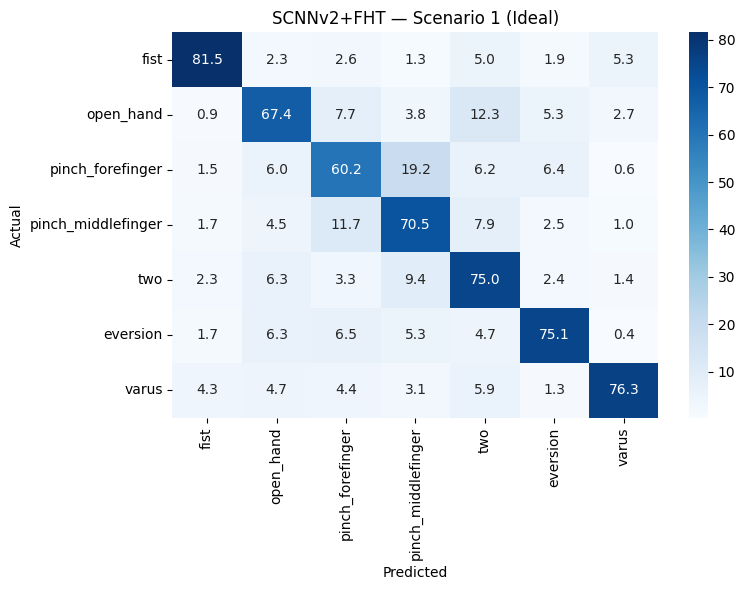

In [6]:
scnn_s1, hist_s1, metrics_s1 = train_and_eval(X_train, y_train, X_test, y_test, "SCNNv2+FHT — Scenario 1 (Ideal)")

In [7]:
# Per-subject evaluation
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["position"] == 0)]

per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]

    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)

    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)

    X_tr_fht = fht_dual_channel(X_tr)
    X_te_fht = fht_dual_channel(X_te)

    m = SeparableCNNv2().to(DEVICE)
    loader = make_loader(X_tr_fht, y_tr, batch_size=128)
    train_model(m, loader, n_epochs=30, lr=1e-3)
    y_pred = predict(m, X_te_fht)
    per_subject_acc[subj] = accuracy_score(y_te, y_pred)

accs = list(per_subject_acc.values())
print(f"Per-subject accuracy: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
print()
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Epoch   1/30 — loss: 1.8875, acc: 0.2441
Epoch   5/30 — loss: 0.9567, acc: 0.7066
Epoch  10/30 — loss: 0.3319, acc: 0.9058
Epoch  15/30 — loss: 0.2608, acc: 0.9122
Epoch  20/30 — loss: 0.2094, acc: 0.9321
Epoch  25/30 — loss: 0.1912, acc: 0.9366
Epoch  30/30 — loss: 0.1934, acc: 0.9391
Epoch   1/30 — loss: 1.9401, acc: 0.1849
Epoch   5/30 — loss: 1.5111, acc: 0.4550
Epoch  10/30 — loss: 0.8238, acc: 0.7235
Epoch  15/30 — loss: 0.5865, acc: 0.8072
Epoch  20/30 — loss: 0.4719, acc: 0.8462
Epoch  25/30 — loss: 0.4347, acc: 0.8470
Epoch  30/30 — loss: 0.3810, acc: 0.8701
Epoch   1/30 — loss: 1.8956, acc: 0.2485
Epoch   5/30 — loss: 0.9049, acc: 0.6656
Epoch  10/30 — loss: 0.3940, acc: 0.8728
Epoch  15/30 — loss: 0.2835, acc: 0.9056
Epoch  20/30 — loss: 0.2114, acc: 0.9331
Epoch  25/30 — loss: 0.1894, acc: 0.9416
Epoch  30/30 — loss: 0.1725, acc: 0.9436
Epoch   1/30 — loss: 1.8801, acc: 0.2718
Epoch   5/30 — loss: 0.9363, acc: 0.6617
Epoch  10/30 — loss: 0.3910, acc: 0.8883
Epoch  15/30 — l

In [8]:
torch.save(scnn_s1.state_dict(), MODELS_DIR / "scnn_v2_s1_ideal.pt")
print("Saved.")

Saved.


---
## Scenario 2 — Electrode Shift

In [9]:
X_train_s2, y_train_s2, test_by_pos, info_s2 = scenario_2_per_position()
print(f"Train: {X_train_s2.shape}")

X_train_s2_fht = fht_dual_channel(X_train_s2)

Loading windows: 100%|██████████| 629/629 [00:00<00:00, 1518.90it/s]


Train: (71927, 8, 50)


In [10]:
scnn_s2 = SeparableCNNv2().to(DEVICE)
loader_s2 = make_loader(X_train_s2_fht, y_train_s2)
hist_s2 = train_model(scnn_s2, loader_s2, n_epochs=30)

Epoch   1/30 — loss: 1.3230, acc: 0.4976
Epoch   5/30 — loss: 0.8869, acc: 0.6767
Epoch  10/30 — loss: 0.7802, acc: 0.7143
Epoch  15/30 — loss: 0.7163, acc: 0.7381
Epoch  20/30 — loss: 0.6906, acc: 0.7455
Epoch  25/30 — loss: 0.6655, acc: 0.7562
Epoch  30/30 — loss: 0.6534, acc: 0.7595


Position  1: acc = 0.3401
Position  2: acc = 0.2575
Position  3: acc = 0.2303
Position  4: acc = 0.1510
Position  5: acc = 0.1889
Position  6: acc = 0.2327
Position  7: acc = 0.3388
Position  8: acc = 0.4105
Position  9: acc = 0.2000
Position 10: acc = 0.1900


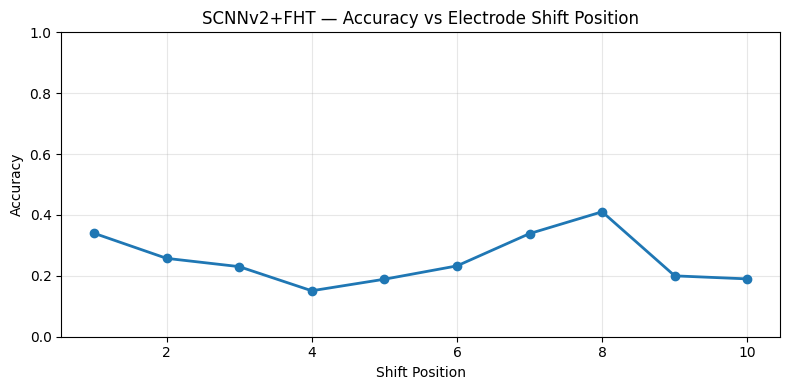

In [11]:
acc_per_pos = {}
for pos, (X_pos, y_pos) in sorted(test_by_pos.items()):
    X_pos_fht = fht_dual_channel(X_pos)
    y_pred = predict(scnn_s2, X_pos_fht)
    acc_per_pos[pos] = accuracy_score(y_pos, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_pos[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_pos.keys()), list(acc_per_pos.values()), "o-", linewidth=2)
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("SCNNv2+FHT — Accuracy vs Electrode Shift Position")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_v2_shift_curve.png"), dpi=150)
plt.show()

In [12]:
torch.save(scnn_s2.state_dict(), MODELS_DIR / "scnn_v2_s2_shift.pt")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject (50 epochs)

In [13]:
X_train_s3, y_train_s3, X_test_s3, y_test_s3, info_s3 = scenario_3_inter_subject()
print(f"Train: {X_train_s3.shape} ({len(info_s3['train_subjects'])} subjects)")
print(f"Test:  {X_test_s3.shape} ({info_s3['test_subjects']})")

Loading windows: 100%|██████████| 1385/1385 [00:00<00:00, 1452.86it/s]


Train: (618926, 8, 50) (24 subjects)
Test:  (168232, 8, 50) (['h7', 'h22', 'h3', 'h24', 'h16', 'h17'])


Applying FHT dual-channel...
Done. Train: (618926, 2, 8, 50), Test: (168232, 2, 8, 50)
Epoch   1/50 — loss: 1.4199, acc: 0.4529
Epoch   5/50 — loss: 1.1655, acc: 0.5579
Epoch  10/50 — loss: 1.0885, acc: 0.5893
Epoch  15/50 — loss: 1.0490, acc: 0.6055
Epoch  20/50 — loss: 1.0368, acc: 0.6115
Epoch  25/50 — loss: 1.0202, acc: 0.6183
Epoch  30/50 — loss: 1.0152, acc: 0.6205
Epoch  35/50 — loss: 1.0067, acc: 0.6239
Epoch  40/50 — loss: 1.0036, acc: 0.6255
Epoch  45/50 — loss: 0.9995, acc: 0.6269
Epoch  50/50 — loss: 0.9974, acc: 0.6272

  SCNNv2+FHT — Scenario 3 (Inter-Subject)
  Accuracy:  0.4734
  F1-macro:  0.4680
                    precision    recall  f1-score   support

              fist       0.49      0.49      0.49     23888
         open_hand       0.44      0.57      0.50     23933
  pinch_forefinger       0.32      0.27      0.29     24284
pinch_middlefinger       0.44      0.34      0.39     24064
               two       0.51      0.51      0.51     23897
          eversion

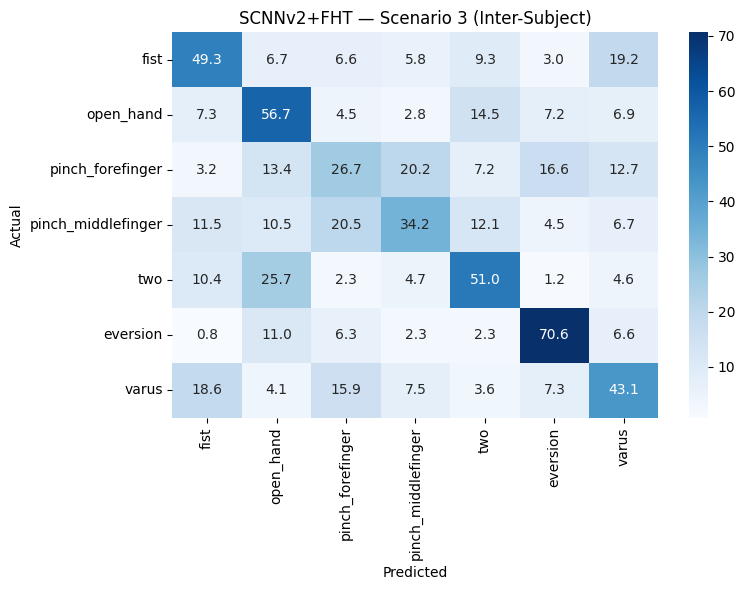

In [14]:
scnn_s3, hist_s3, metrics_s3 = train_and_eval(
    X_train_s3, y_train_s3, X_test_s3, y_test_s3,
    "SCNNv2+FHT — Scenario 3 (Inter-Subject)", n_epochs=50
)

In [15]:
torch.save(scnn_s3.state_dict(), MODELS_DIR / "scnn_v2_s3_intersubject.pt")
print("Saved.")

Saved.


---
## Scenario 4 — Inter-Day

In [16]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")

X_train_s4_fht = fht_dual_channel(X_train_s4)

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 1489.08it/s]


Train: (13445, 8, 50)


In [17]:
scnn_s4 = SeparableCNNv2().to(DEVICE)
loader_s4 = make_loader(X_train_s4_fht, y_train_s4)
hist_s4 = train_model(scnn_s4, loader_s4, n_epochs=30)

Epoch   1/30 — loss: 1.6755, acc: 0.3455
Epoch   5/30 — loss: 0.7799, acc: 0.7172
Epoch  10/30 — loss: 0.5900, acc: 0.7811
Epoch  15/30 — loss: 0.5347, acc: 0.8026
Epoch  20/30 — loss: 0.5020, acc: 0.8132
Epoch  25/30 — loss: 0.4708, acc: 0.8258
Epoch  30/30 — loss: 0.4574, acc: 0.8269


Session 1: acc = 0.5367
Session 2: acc = 0.6550
Session 3: acc = 0.6449
Session 4: acc = 0.6837
Session 5: acc = 0.5804
Session 6: acc = 0.6743
Session 7: acc = 0.5556
Session 8: acc = 0.6493
Session 9: acc = 0.5211


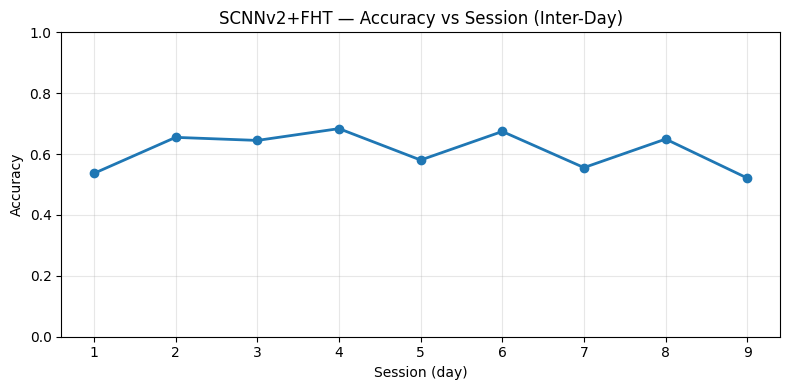

In [18]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    X_s_fht = fht_dual_channel(X_s)
    y_pred = predict(scnn_s4, X_s_fht)
    acc_per_sess[sess] = accuracy_score(y_s, y_pred)
    print(f"Session {sess}: acc = {acc_per_sess[sess]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_sess.keys()), list(acc_per_sess.values()), "o-", linewidth=2)
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("SCNNv2+FHT — Accuracy vs Session (Inter-Day)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_v2_interday_curve.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue

In [19]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")

X_train_s5_fht = fht_dual_channel(X_train_s5)

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 1590.50it/s]


Train: (33046, 8, 50)


In [20]:
scnn_s5 = SeparableCNNv2().to(DEVICE)
loader_s5 = make_loader(X_train_s5_fht, y_train_s5)
hist_s5 = train_model(scnn_s5, loader_s5, n_epochs=30)

Epoch   1/30 — loss: 1.2699, acc: 0.5096
Epoch   5/30 — loss: 0.4424, acc: 0.8377
Epoch  10/30 — loss: 0.3653, acc: 0.8672
Epoch  15/30 — loss: 0.3273, acc: 0.8804
Epoch  20/30 — loss: 0.3098, acc: 0.8873
Epoch  25/30 — loss: 0.2943, acc: 0.8912
Epoch  30/30 — loss: 0.2871, acc: 0.8933


Position  2: acc = 0.8721
Position  3: acc = 0.8622
Position  4: acc = 0.8671
Position  5: acc = 0.8761
Position  6: acc = 0.8619
Position  7: acc = 0.8847
Position  8: acc = 0.8301
Position  9: acc = 0.8400
Position 10: acc = 0.8379


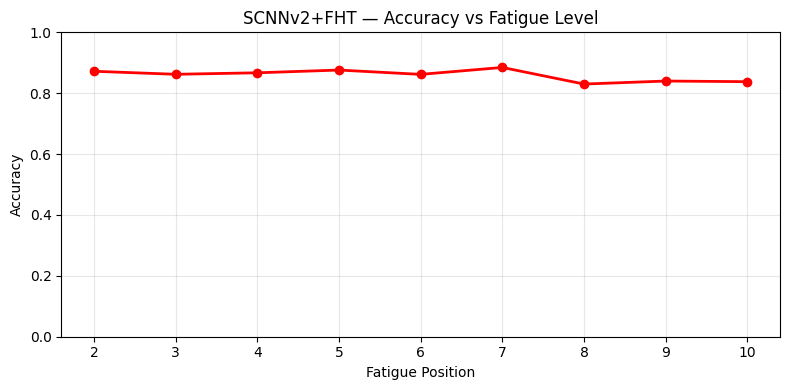

In [21]:
acc_per_fatigue = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    X_p_fht = fht_dual_channel(X_p)
    y_pred = predict(scnn_s5, X_p_fht)
    acc_per_fatigue[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_fatigue[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_fatigue.keys()), list(acc_per_fatigue.values()), "o-", linewidth=2, color="red")
plt.xlabel("Fatigue Position")
plt.ylabel("Accuracy")
plt.title("SCNNv2+FHT — Accuracy vs Fatigue Level")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_v2_fatigue_curve.png"), dpi=150)
plt.show()

---
## Latency Measurement

In [22]:
scnn_s1.eval()
sample_raw = X_train[:1]  # (1, 8, 50)

# Warm-up
sample_fht = torch.from_numpy(fht_dual_channel(sample_raw)).float().to(DEVICE)
for _ in range(10):
    _ = scnn_s1(sample_fht)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def scnn_v2_predict_single(x_raw):
    x_fht = fht_dual_channel(x_raw)
    x_t = torch.from_numpy(x_fht).float().to(DEVICE)
    with torch.no_grad():
        out = scnn_s1(x_t)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

latency = measure_latency(scnn_v2_predict_single, sample_raw, n_runs=500)
print_latency(latency, model_name="SCNNv2+FHT (dual-channel FHT + inference)")
print(f"Parameters: {sum(p.numel() for p in scnn_s1.parameters()):,}")


Latency — SCNNv2+FHT (dual-channel FHT + inference)
  Mean:   1.83 ms
  Median: 1.69 ms
  P95:    2.14 ms
  <300ms: ✓
Parameters: 20,667


---
## Summary & Full Comparison

In [23]:
n_params = sum(p.numel() for p in scnn_s1.parameters())

print("\n" + "=" * 60)
print("FULL COMPARISON — ALL METHODS")
print("=" * 60)
print(f"{'Metric':<22} {'SVM':>8} {'CNN':>8} {'SCNN v1':>8} {'SCNN v2':>8}")
print("-" * 60)
print(f"{'S1 Ideal':<22} {'65.19%':>8} {'75.78%':>8} {'71.80%':>8} {metrics_s1['accuracy']*100:>7.2f}%")
print(f"{'S2 Shift (avg)':<22} {'23.99%':>8} {'26.41%':>8} {'24.78%':>8} {np.mean(list(acc_per_pos.values()))*100:>7.2f}%")
print(f"{'S3 Inter-subject':<22} {'40.27%':>8} {'52.90%':>8} {'48.51%':>8} {metrics_s3['accuracy']*100:>7.2f}%")
print(f"{'S4 Inter-day':<22} {'63.03%':>8} {'67.30%':>8} {'62.79%':>8} {np.mean(list(acc_per_sess.values()))*100:>7.2f}%")
print(f"{'S5 Fatigue':<22} {'81.20%':>8} {'86.98%':>8} {'84.96%':>8} {np.mean(list(acc_per_fatigue.values()))*100:>7.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>8} {'1.74':>8} {'2.10':>8} {latency['p95_ms']:>7.2f}")
print(f"{'Parameters':<22} {'—':>8} {'101,831':>8} {'20,625':>8} {n_params:>8,}")
print("=" * 60)


FULL COMPARISON — ALL METHODS
Metric                      SVM      CNN  SCNN v1  SCNN v2
------------------------------------------------------------
S1 Ideal                 65.19%   75.78%   71.80%   72.27%
S2 Shift (avg)           23.99%   26.41%   24.78%   25.40%
S3 Inter-subject         40.27%   52.90%   48.51%   47.34%
S4 Inter-day             63.03%   67.30%   62.79%   61.12%
S5 Fatigue               81.20%   86.98%   84.96%   85.91%
Latency p95 (ms)           5.40     1.74     2.10    2.14
Parameters                    —  101,831   20,625   20,667
